### **Data_Science_Projet0: Analyse d'une campagne marketing**

Si avoir des compétences techniques telles que la programmation, les statistiques, le nettoyage
de données, le Machine Learning, ..., est absolument incontournable pour un Data Worker, le
plus grand défi est de comprendre comment ces compétences et concepts se traduisent dans le
monde réel et de pouvoir les appliquer pour résoudre des problèmes en entreprises.(En plus 99% des Seniors donnent mettent toujours un accent la dessus)  


L'un des domaines majeurs où la Data Science peut s'appliquer dans une entreprise est le Marketing.  

En effet dans une équipe marketing, un Data Scientist a pour rôle d'aider l'entreprise à comprendre
l'impact de ses campagnes marketing. Il peut donc effectuer plusieurs tâches dont :  
•L'analyse d'indicateurs clés de performance ;  
•L'analyse du fonctionnement des différents canaux marketing (Ex : Combien de
nouveaux utilisateurs s'abonnent par suite de l'envoi de courriels ; Compte tenu des taux
de conversion et des revenus actuels, est-ce que l'entreprise doit continuer à investir
dans tel ou tel autre canal et combien doit-elle dépenser ? etc.) ;  
•L'exécution d'expériences (A/B Tests) pour comprendre l'impact d'un changement
particulier.  

A travers ce projet, mon objectif principal sera de m'entraîner à traduire les questions commerciales courantes en
résultats mesurables, notamment : "Comment une campagne marketing a-t-elle fonctionné ?",
"Quel canal d'acquisition réfère le plus d'abonnés ?", "Pourquoi un canal particulier est-il sous-
performant ?" Nous utiliserons les données marketing d'une entreprise d'abonnement en ligne.

In [ ]:
import pandas as pd #Maniplulation des données
import numpy as np #Calcul scientifique/Numerique/Vectorielle
import matplotlib.pyplot as plt #Dessin
import seaborn as sns #Dessin graphique aussi

In [ ]:
#Importation des données
marketing_df = pd.read_csv("https://raw.githubusercontent.com/JosueAfouda/Marketing-Pandas/master/marketing.csv")
marketing_df

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained
0,a100000029,1/1/18,House Ads,personalization,True,English,English,0-18 years,1/1/18,NaN,House Ads,True
1,a100000030,1/1/18,House Ads,personalization,True,English,English,19-24 years,1/1/18,NaN,House Ads,True
2,a100000031,1/1/18,House Ads,personalization,True,English,English,24-30 years,1/1/18,NaN,House Ads,True
3,a100000032,1/1/18,House Ads,personalization,True,English,English,30-36 years,1/1/18,NaN,House Ads,True
4,a100000033,1/1/18,House Ads,personalization,True,English,English,36-45 years,1/1/18,NaN,House Ads,True
...,...,...,...,...,...,...,...,...,...,...,...,...
10032,a100007290,1/17/18,Email,control,True,German,German,45-55 years,1/17/18,1/24/18,Email,False
10033,a100007291,1/17/18,Email,control,True,German,German,55+ years,1/17/18,NaN,Email,True
10034,a100007292,1/5/18,Instagram,control,False,German,German,55+ years,1/17/18,NaN,Email,True
10035,a100007293,1/17/18,Email,control,True,German,German,0-18 years,1/17/18,NaN,Email,True


In [ ]:
marketing_df.columns

Index(['user_id', 'date_served', 'marketing_channel', 'variant', 'converted',
       'language_displayed', 'language_preferred', 'age_group',
       'date_subscribed', 'date_canceled', 'subscribing_channel',
       'is_retained'],
      dtype='object')

In [ ]:
colonnes_vf = {'user_id':'id_utilisateur', 'date_served':'date_exposition_publicite', 'marketing_channel':'canal_marketing',
               'variant':'variante', 'converted':'converti','language_displayed':'langue_de_publicite',
               'language_preferred':'langue_preferee', 'age_group':'tranche_d_age','date_subscribed':'date_souscription',
               'date_canceled':'date_desinscription', 'subscribing_channel':'canal_d_abonnement','is_retained':'retention_active/client_fidele'}
marketing_df = marketing_df.rename(columns=colonnes_vf)

In [ ]:
marketing_df

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,id_utilisateur,date_exposition_publicite,canal_marketing,variante,converti,langue_de_publicite,langue_preferee,tranche_d_age,date_souscription,date_desinscription,canal_d_abonnement,retention_active/client_fidele
0,a100000029,1/1/18,House Ads,personalization,True,English,English,0-18 years,1/1/18,NaN,House Ads,True
1,a100000030,1/1/18,House Ads,personalization,True,English,English,19-24 years,1/1/18,NaN,House Ads,True
2,a100000031,1/1/18,House Ads,personalization,True,English,English,24-30 years,1/1/18,NaN,House Ads,True
3,a100000032,1/1/18,House Ads,personalization,True,English,English,30-36 years,1/1/18,NaN,House Ads,True
4,a100000033,1/1/18,House Ads,personalization,True,English,English,36-45 years,1/1/18,NaN,House Ads,True
...,...,...,...,...,...,...,...,...,...,...,...,...
10032,a100007290,1/17/18,Email,control,True,German,German,45-55 years,1/17/18,1/24/18,Email,False
10033,a100007291,1/17/18,Email,control,True,German,German,55+ years,1/17/18,NaN,Email,True
10034,a100007292,1/5/18,Instagram,control,False,German,German,55+ years,1/17/18,NaN,Email,True
10035,a100007293,1/17/18,Email,control,True,German,German,0-18 years,1/17/18,NaN,Email,True


In [ ]:
marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10037 entries, 0 to 10036
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_utilisateur                  10037 non-null  object
 1   date_exposition_publicite       10021 non-null  object
 2   canal_marketing                 10022 non-null  object
 3   variante                        10037 non-null  object
 4   converti                        10022 non-null  object
 5   langue_de_publicite             10037 non-null  object
 6   langue_preferee                 10037 non-null  object
 7   tranche_d_age                   10037 non-null  object
 8   date_souscription               1856 non-null   object
 9   date_desinscription             577 non-null    object
 10  canal_d_abonnement              1856 non-null   object
 11  retention_active/client_fidele  1856 non-null   object
dtypes: object(12)
memory usage: 941.1+ KB


Les variables date_served, date_subscribed et date_canceled sont des dates et ne sont pas au
bon format. Nous mettrons ces variables au format 'Datetime'

In [ ]:
for colonne in ["date_exposition_publicite","date_souscription","date_desinscription"]:
    marketing_df[colonne] = pd.to_datetime(marketing_df[colonne],errors="coerce")

/tmp/ipython-input-2825588398.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  marketing_df[colonne] = pd.to_datetime(marketing_df[colonne],errors="coerce")
/tmp/ipython-input-2825588398.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  marketing_df[colonne] = pd.to_datetime(marketing_df[colonne],errors="coerce")
/tmp/ipython-input-2825588398.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  marketing_df[colonne] = pd.to_datetime(marketing_df[colonne],errors="coerce")


In [ ]:
marketing_df.dtypes

,0
id_utilisateur,object
date_exposition_publicite,datetime64[ns]
canal_marketing,object
variante,object
converti,object
langue_de_publicite,object
langue_preferee,object
tranche_d_age,object
date_souscription,datetime64[ns]
date_desinscription,datetime64[ns]


In [ ]:
#Obtenons un résumé statistique de la DataFrame
marketing_df.describe().T


,count,mean,min,25%,50%,75%,max
date_exposition_publicite,10021,2018-01-15 05:02:03.221235712,2018-01-01 00:00:00,2018-01-08 00:00:00,2018-01-15 00:00:00,2018-01-22 00:00:00,2018-01-31 00:00:00
date_souscription,1856,2018-01-14 02:04:08.275862016,2018-01-01 00:00:00,2018-01-07 00:00:00,2018-01-15 00:00:00,2018-01-19 00:00:00,2018-01-31 00:00:00
date_desinscription,577,2018-03-03 18:28:04.575389952,2018-01-05 00:00:00,2018-02-07 00:00:00,2018-03-04 00:00:00,2018-04-01 00:00:00,2018-05-09 00:00:00


In [ ]:
"""
En utilisant les données, répondrons à des questions très importantes pour l’entreprise:
-Quels sont les canaux marketing que l'entreprise utilise?
"""
marketing_df["canal_marketing"].value_counts()

,count
canal_marketing,
House Ads,4733
Instagram,1871
Facebook,1860
Push,993
Email,565


In [ ]:
#Pour avoir plutôt les proportions :
marketing_df["canal_marketing"].value_counts(normalize = True)

,proportion
canal_marketing,
House Ads,0.472261
Instagram,0.186689
Facebook,0.185592
Push,0.099082
Email,0.056376


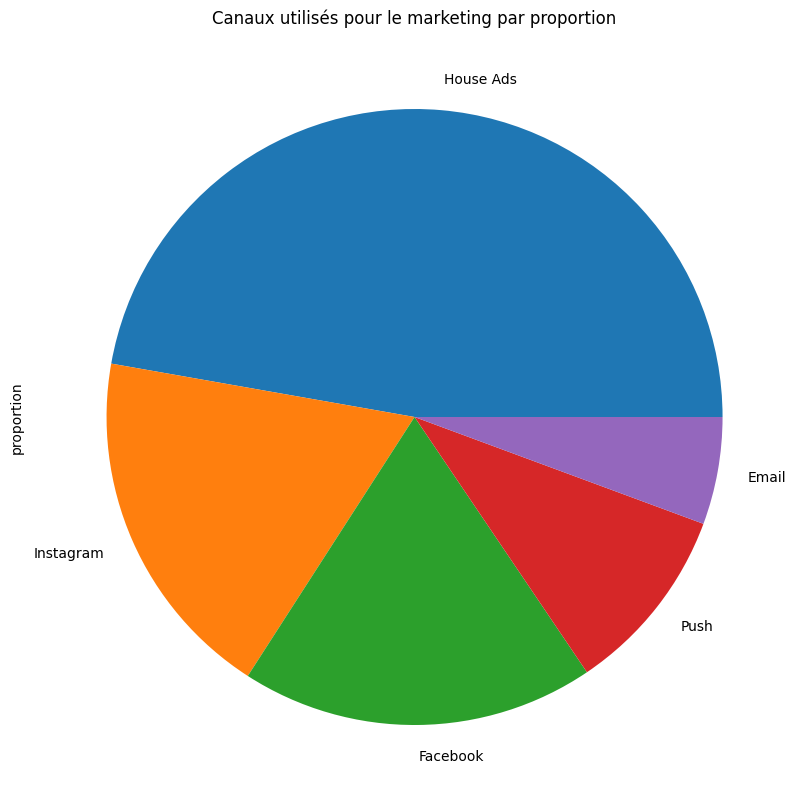

In [ ]:
"""
L'entreprise utilise majoritairement (un peu plus de 47%) pour les annonces auto-promotionnelle
Essayons de representer tout cela part un pie-chart (Diagramme circulaire)

"""
plt.figure(figsize = (10,10))
marketing_df["canal_marketing"].value_counts(normalize = True).plot(kind = "pie")
plt.title("Canaux utilisés pour le marketing par proportion")
plt.show()

In [ ]:
#Quelle est le nombre d’utilisateurs retenus (ou fidelisés)par la campagne marketing ?
marketing_df["retention_active/client_fidele"].sum()


1279

In [ ]:
marketing_df["retention_active/client_fidele"].value_counts(normalize = True)

,proportion
retention_active/client_fidele,
True,0.689116
False,0.310884


Le nombre d’utilisateurs retenus par la campagne marketing est 1279 ce qui fait en pourcentage a peu pres 69%

In [ ]:
"""
Nous voulons créer une nouvelle variable par encodage des modalités de la variable
canal_d_abonnement :

"""
#Dans un premier temps veuillons verifier les types distincts de la colonne "canal_d_abonnement"
marketing_df["canal_d_abonnement"].unique()

array(['House Ads', 'Email', 'Push', 'Facebook', 'Instagram', nan],
      dtype=object)

In [ ]:
dict_canaux = {"House Ads":1, "Email":2, "Push":3, "Facebook":4, "Instagram":5}
#Créons a partir de ce dictionnaire la colonne encodé canaux_encodes
marketing_df["canaux_encodes"] = marketing_df["canal_d_abonnement"].map(dict_canaux)
marketing_df

,id_utilisateur,date_exposition_publicite,canal_marketing,variante,converti,langue_de_publicite,langue_preferee,tranche_d_age,date_souscription,date_desinscription,canal_d_abonnement,retention_active/client_fidele,canaux_encodes
0,a100000029,2018-01-01,House Ads,personalization,True,English,English,0-18 years,2018-01-01,NaT,House Ads,True,1.0
1,a100000030,2018-01-01,House Ads,personalization,True,English,English,19-24 years,2018-01-01,NaT,House Ads,True,1.0
2,a100000031,2018-01-01,House Ads,personalization,True,English,English,24-30 years,2018-01-01,NaT,House Ads,True,1.0
3,a100000032,2018-01-01,House Ads,personalization,True,English,English,30-36 years,2018-01-01,NaT,House Ads,True,1.0
4,a100000033,2018-01-01,House Ads,personalization,True,English,English,36-45 years,2018-01-01,NaT,House Ads,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10032,a100007290,2018-01-17,Email,control,True,German,German,45-55 years,2018-01-17,2018-01-24,Email,False,2.0
10033,a100007291,2018-01-17,Email,control,True,German,German,55+ years,2018-01-17,NaT,Email,True,2.0
10034,a100007292,2018-01-05,Instagram,control,False,German,German,55+ years,2018-01-17,NaT,Email,True,2.0
10035,a100007293,2018-01-17,Email,control,True,German,German,0-18 years,2018-01-17,NaT,Email,True,2.0


In [ ]:
"""
Ajoutons une nouvelle colonne is_correct_lang qui est égale à 'Yes' si l'utilisateur a vu l'annonce
marketing dans sa langue préférée et 'No' dans le cas contraire.

"""
marketing_df["langue_appropriee"] = np.where(marketing_df["langue_de_publicite"] == marketing_df["langue_preferee"],"Yes","No")
marketing_df

,id_utilisateur,date_exposition_publicite,canal_marketing,variante,converti,langue_de_publicite,langue_preferee,tranche_d_age,date_souscription,date_desinscription,canal_d_abonnement,retention_active/client_fidele,canaux_encodes,langue_appropriee
0,a100000029,2018-01-01,House Ads,personalization,True,English,English,0-18 years,2018-01-01,NaT,House Ads,True,1.0,Yes
1,a100000030,2018-01-01,House Ads,personalization,True,English,English,19-24 years,2018-01-01,NaT,House Ads,True,1.0,Yes
2,a100000031,2018-01-01,House Ads,personalization,True,English,English,24-30 years,2018-01-01,NaT,House Ads,True,1.0,Yes
3,a100000032,2018-01-01,House Ads,personalization,True,English,English,30-36 years,2018-01-01,NaT,House Ads,True,1.0,Yes
4,a100000033,2018-01-01,House Ads,personalization,True,English,English,36-45 years,2018-01-01,NaT,House Ads,True,1.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10032,a100007290,2018-01-17,Email,control,True,German,German,45-55 years,2018-01-17,2018-01-24,Email,False,2.0,Yes
10033,a100007291,2018-01-17,Email,control,True,German,German,55+ years,2018-01-17,NaT,Email,True,2.0,Yes
10034,a100007292,2018-01-05,Instagram,control,False,German,German,55+ years,2018-01-17,NaT,Email,True,2.0,Yes
10035,a100007293,2018-01-17,Email,control,True,German,German,0-18 years,2018-01-17,NaT,Email,True,2.0,Yes


In [ ]:
#Ajoutons une colonne jour_de_semaine qui veut dire tout simplement jour de la semaine
marketing_df["jour_de_semaine"] = marketing_df["date_souscription"].dt.dayofweek
marketing_df

,id_utilisateur,date_exposition_publicite,canal_marketing,variante,converti,langue_de_publicite,langue_preferee,tranche_d_age,date_souscription,date_desinscription,canal_d_abonnement,retention_active/client_fidele,canaux_encodes,langue_appropriee,jour_de_semaine
0,a100000029,2018-01-01,House Ads,personalization,True,English,English,0-18 years,2018-01-01,NaT,House Ads,True,1.0,Yes,0.0
1,a100000030,2018-01-01,House Ads,personalization,True,English,English,19-24 years,2018-01-01,NaT,House Ads,True,1.0,Yes,0.0
2,a100000031,2018-01-01,House Ads,personalization,True,English,English,24-30 years,2018-01-01,NaT,House Ads,True,1.0,Yes,0.0
3,a100000032,2018-01-01,House Ads,personalization,True,English,English,30-36 years,2018-01-01,NaT,House Ads,True,1.0,Yes,0.0
4,a100000033,2018-01-01,House Ads,personalization,True,English,English,36-45 years,2018-01-01,NaT,House Ads,True,1.0,Yes,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10032,a100007290,2018-01-17,Email,control,True,German,German,45-55 years,2018-01-17,2018-01-24,Email,False,2.0,Yes,2.0
10033,a100007291,2018-01-17,Email,control,True,German,German,55+ years,2018-01-17,NaT,Email,True,2.0,Yes,2.0
10034,a100007292,2018-01-05,Instagram,control,False,German,German,55+ years,2018-01-17,NaT,Email,True,2.0,Yes,2.0
10035,a100007293,2018-01-17,Email,control,True,German,German,0-18 years,2018-01-17,NaT,Email,True,2.0,Yes,2.0


In [ ]:
"""
UTILISATEURS UNIQUES QUI VOIENT LES ANNONCES MARKETING CHAQUE
JOUR
Ceci est crucial pour comprendre l'efficacité des efforts marketing au cours du dernier mois.
Pour répondre à cette question, il faut grouper les observations (lignes de la dataframe) par la
variable date_served et compter le nombre d’utilisateurs (variable user_id)

"""
utilisateurs_qui_voient_les_annonces_quotidiennement = marketing_df.groupby("date_exposition_publicite")["id_utilisateur"].nunique()
utilisateurs_qui_voient_les_annonces_quotidiennement

,id_utilisateur
date_exposition_publicite,
2018-01-01,362
2018-01-02,374
2018-01-03,348
2018-01-04,323
2018-01-05,319
2018-01-06,308
2018-01-07,275
2018-01-08,312
2018-01-09,312


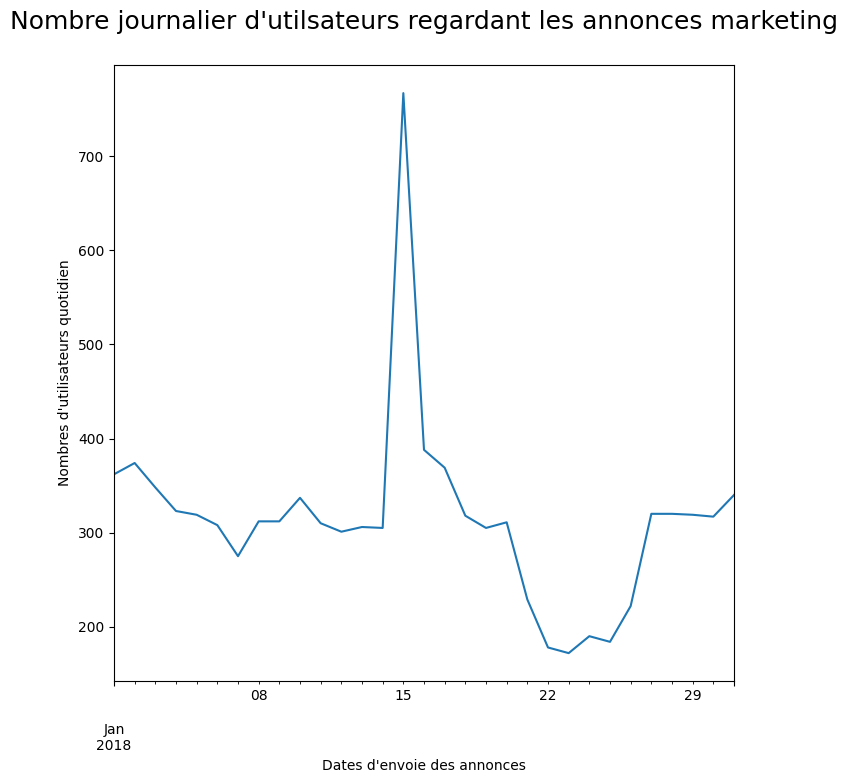

In [ ]:
#Visualisation des résultats
plt.figure(figsize = (8,8))
utilisateurs_qui_voient_les_annonces_quotidiennement.plot.line()
plt.xlabel("Dates d'envoie des annonces")
plt.ylabel("Nombres d'utilisateurs quotidien")
plt.title("Nombre journalier d'utilsateurs regardant les annonces marketing\n", fontsize = 18)
plt.show()

**Alors que la première moitié du mois enregistre entre 300 et 400 utilisateurs par jour,  il y a eu un énorme pic au milieu du mois. Cela peut être dû au fait que l'entreprise a   déployé une grosse campagne par mail qui a atteint plusieurs utilisateurs qui n’étaient pas des visiteurs quotidiens du site.**

QUELQUES INDICATEURS CLES DE PERFORMANCE
Une campagne marketing a-t-elle réussi ? Il y a plusieurs manières de mesurer le succès  d'une
campagne. Le taux de conversion et le taux de rétention sont très souvent utilisés.  

❖ TAUX DE CONVERSION:  

Parmi toutes les personnes qui sont entrées en contact avec la campagne, combien ont acheté le
produit ou combien se sont abonnés au service de l’entreprise (cela dépend du type de business
et de l'objectif fixé au départ) ? C'est le taux de conversion qui permet de répondre à cette
question. Le taux de conversion est le nombre de personnes converties sur le nombre total de
personnes touchés par la campagne. On peut parler de conversion en termes d'achats ou en
termes d'abonnement à un service par exemple. En termes d'abonnement à un service, le taux
de conversion est le pourcentage des utilisateurs qui ont vu les annonces marketing et se sont
ensuite abonnés.

❖ TAUX DE RETENTION:  
Une fois que l'utilisateur s'est abonné, l'est-il toujours après 1 mois, 3 mois ou 1 an ? Le taux
de rétention est le pourcentage de personnes qui restent abonnées après une certaine période de
temps.
Calculons le taux de conversion global.



1.   **Taux de conversion globale**




In [ ]:
n_unique_utilisateurs = marketing_df["id_utilisateur"].nunique()#Nombres d'utilisateurs distincts
print("Le nombre distincts d'utilisateurs est:", n_unique_utilisateurs)

Le nombre distincts d'utilisateurs est: 7309


In [ ]:
#Nombre d'utilisateurs uniques ayant souscrit au service
n_souscrits = marketing_df[marketing_df["converti"] == True]["id_utilisateur"].nunique()
print("Le nombre d'utilisateurs s'ayant abonné(souscrit) au service est:",n_souscrits)

Le nombre d'utilisateurs s'ayant abonné(souscrit) au service est: 1015


In [ ]:
#Taux de conversion global
total_conversion_rate = n_souscrits/n_unique_utilisateurs
print('\n')
print("Le taux de conversion global est égal à :", round(total_conversion_rate *100, 2), "%")



Le taux de conversion global est égal à : 13.89 %


**Le nombre distincts d'utilisateurs est: 7309**  
**Le nombre d'utilisateurs s'ayant abonné(souscrit) au service est: 1015**  
**Le taux de conversion global est égal à : 13.89 %**

On pourrait peut-etre se demander, est-ce un bon taux de conversion ? Cela dépendra fortement l'entreprise. Il n'y a pas de nombre particulier que toutes les équipes marketing tentent
d'atteindre. Au lieu de cela, lorsque vous travaillez dans une équipe marketing, il est utile
d'examiner les données historiques pour déterminer si un taux de conversion correspond à ce
dont vous pouvez vous attendre.

On va devoir calculer le taux de rétention ou le nombre d'abonnés restants des utilisateurs qui se sont
convertis à votre produit. Cela vous permettra de savoir si votre campagne marketing a converti
des abonnés réellement intéressés par le produit.

Il est possible de créer une entreprise avec un taux de conversion élevé en offrant aux
utilisateurs un essai gratuit, mais avoir un faible taux de rétention une fois que les utilisateurs
sont facturés pour vos services. Ce n'est pas intrinsèquement une mauvaise chose, mais il est
important de fournir aux parties prenantes (décideurs et actionnaires) de votre entreprise un
aperçu du pourcentage d'utilisateurs qui restent abonnés.  


Calculons donc le taux de rétention global !

In [ ]:
#Calculons le taux de rétention global d'un mois
#Nombre d'utilisateurs qui sont restés abonnés
n_unique_clients_fideles = marketing_df[marketing_df["retention_active/client_fidele"] == True]["id_utilisateur"].nunique()
print("Le nombre d'utilisateurs toujours souscrit au service au bout de un mois est:",n_unique_clients_fideles)

Le nombre d'utilisateurs toujours souscrit au service au bout de un mois est: 678


In [ ]:
taux_global_de_retention = n_unique_clients_fideles/n_souscrits
print('\n')
print("Le taux de retention global est égal à :", round(taux_global_de_retention*100, 2), "%")



Le taux de retention global est égal à : 66.8 %


Tout comme avec le taux de conversion, il n'y a pas de taux de rétention standard qui
s'appliquera aux entreprises et aux industries. Regardez les taux de rétention historiques ou les
taux de rétention d'entreprises dans un secteur similaire pour interpréter vos résultats.

**SEGMENTATION DE CLIENTELE**   
Au lieu de calculer par exemple les taux de conversion et de rétention de l'ensemble, on peut
les calculer par groupe d'âge par exemple. Le fait de grouper les clients selon certaines de leurs
caractéristiques similaires est une technique appelée segmentation. Elle permet de faire des
analyses plus approfondies et d'effectuer des campagnes marketing beaucoup plus ciblées.

**❖ TAUX DE RETENTION PAR CANAL DE SOUSCRIPTION**  
Pour obtenir le taux de rétention pour un canal de souscription, il faudra calculer le nombre
total d'utilisateurs retenus par ce canal divisé par le nombre total d'utilisateurs ayant souscrit à
un abonnement via ce canal.

In [ ]:
n_retentions_par_canal = marketing_df[marketing_df["retention_active/client_fidele"] == True].groupby("canal_d_abonnement")["id_utilisateur"].nunique()
n_retentions_par_canal

,id_utilisateur
canal_d_abonnement,
Email,141
Facebook,152
House Ads,173
Instagram,158
Push,54


In [ ]:
"""Pour chaque canal de souscription, determinons le nombre de personne ayant souscrit a un abonnement sur le site(Les "convertis")"""
n_convertis_par_canal =  marketing_df[marketing_df["converti"] == True].groupby("canal_d_abonnement")["id_utilisateur"].nunique()
n_convertis_par_canal

,id_utilisateur
canal_d_abonnement,
Email,161
Facebook,221
House Ads,298
Instagram,232
Push,77


In [ ]:
"""
Nous pouvons maintenant calculer le taux de rétention pour chacun des canaux de souscription :
"""
taux_retention_par_canal = (n_retentions_par_canal/n_convertis_par_canal)*100
taux_retention_par_canal

,id_utilisateur
canal_d_abonnement,
Email,87.577640
Facebook,68.778281
House Ads,58.053691
Instagram,68.103448
Push,70.129870


In [ ]:
taux_retention_par_canal.sort_values(ascending = False)

,id_utilisateur
canal_d_abonnement,
Email,87.577640
Push,70.129870
Facebook,68.778281
Instagram,68.103448
House Ads,58.053691


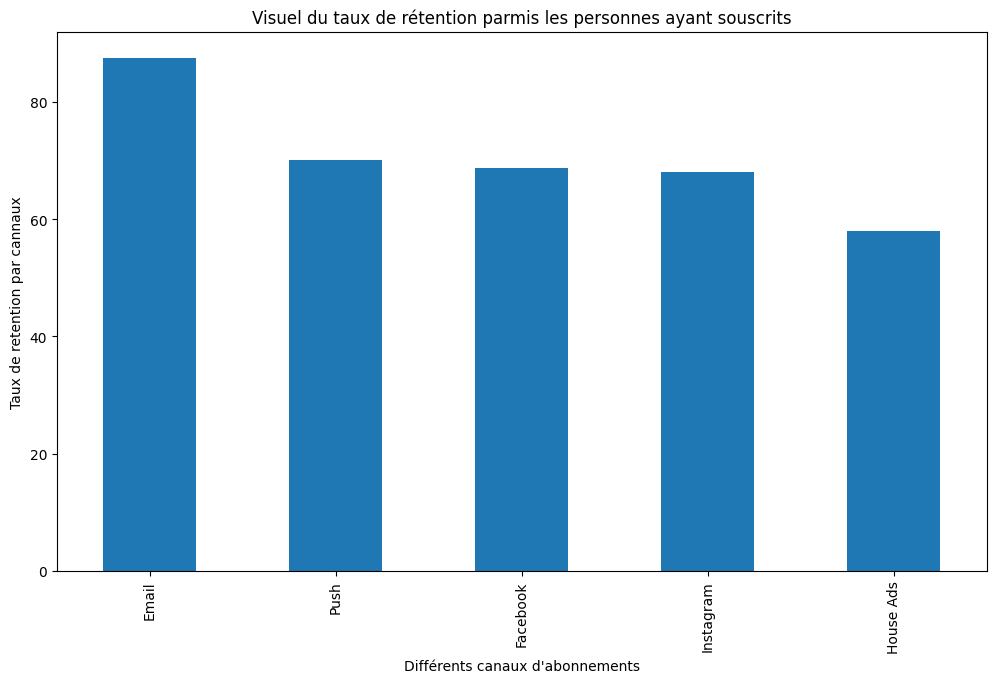

In [ ]:
########################################################
#-Visualisation des résultats
########################################################
plt.figure(figsize=(12,7))
taux_retention_par_canal.sort_values(ascending= False).plot(kind="bar")
plt.title("Visuel du taux de rétention parmis les personnes ayant souscrits")
plt.xlabel("Différents canaux d'abonnements")
plt.ylabel("Taux de retention par cannaux")
plt.show()


Les courriers électroniques présentent le taux de rétention le plus élevé parmi les canaux de
souscription au service de cette entreprise.

❖ AUTOMATISATION DU CALCUL DE TAUX DE RETENTION   
Puisque nous allons devoir calculer à plusieurs reprises le taux de rétention pour différents
segments, définissons une fonction qui nous permettra d'automatiser ce calcul afin de ne pas
recopier du code.

In [ ]:
def taux_de_retention(dataframe, noms_colonnes):
    fidelisees = dataframe[dataframe['retention_active/client_fidele'] == True].groupby(noms_colonnes)['id_utilisateur'].nunique()
    convertis = dataframe[dataframe['converti'] == True].groupby(noms_colonnes)['id_utilisateur'].nunique()
    taux_de_retention = fidelisees/convertis
    return taux_de_retention

La fonction a donné le même résultat que précédemment donc elle marche bien. Appliquons
cette fonction pour calculer le taux de rétention selon la langue d’affichage de l’annonce.

In [ ]:
# Taux de rétention par langue affichée ou langue de puplicité
taux_de_retention_par_langage_d_annonce = taux_de_retention(marketing_df, ["langue_de_publicite"])
taux_de_retention_par_langage_d_annonce

,id_utilisateur
langue_de_publicite,
Arabic,0.750000
English,0.668467
German,0.773585
Spanish,1.000000


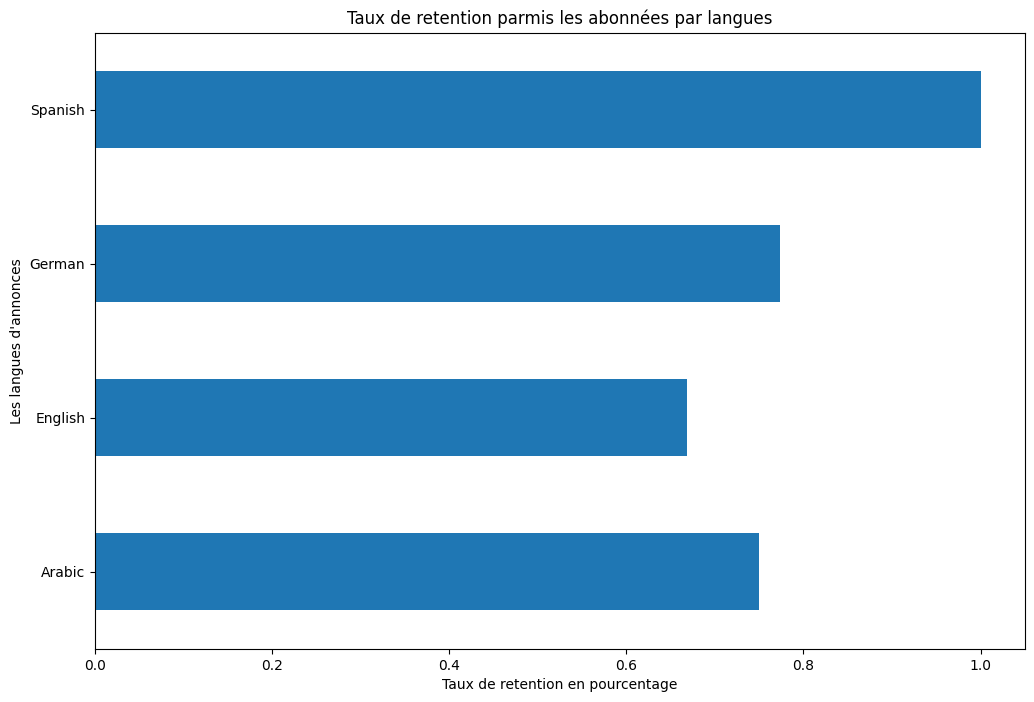

In [ ]:
#Visualisation des resultats
plt.figure(figsize=(12,8))
taux_de_retention_par_langage_d_annonce.plot(kind= "barh")
plt.title("Taux de retention parmis les abonnées par langues")
plt.xlabel("Taux de retention en pourcentage")
plt.ylabel("Les langues d'annonces")
plt.show()

L'Espagnol offre le meilleur taux de rétention (environ 100%).

❖ TAUX DE CONVERSION PAR CANAL D'ACQUISITION

In [ ]:
#Nombres d'utilisateurs uniques ayant souscrit a un service

In [ ]:
#Nombre d'utilisateurs uniques ayant souscrit au service par cannaux
n_utilisateurs_ayant_souscrit_par_le_canal = marketing_df[marketing_df["converti"] == True].groupby("canal_d_abonnement")['id_utilisateur'].nunique()
print("Le nombre d'utilisateurs s'ayant abonné(souscrit) au service est:",n_utilisateurs_ayant_souscrit_par_le_canal)

Le nombre d'utilisateurs s'ayant abonné(souscrit) au service est: canal_d_abonnement
Email        161
Facebook     221
House Ads    298
Instagram    232
Push          77
Name: id_utilisateur, dtype: int64


In [ ]:
#Nombres de personnes atteints par canal
n_personnes_ayant_visite_le_canal = marketing_df.groupby("canal_d_abonnement")['id_utilisateur'].nunique()
print("Le nombre d'utilisateurs s'ayant abonné(souscrit) au service est:",n_personnes_ayant_visite_le_canal)

Le nombre d'utilisateurs s'ayant abonné(souscrit) au service est: canal_d_abonnement
Email        192
Facebook     221
House Ads    298
Instagram    232
Push          77
Name: id_utilisateur, dtype: int64


In [ ]:
#Calculons plus aisement le taux de personnes ayant souscrit au service par un canal
taux_conversion_par_canal_dacquisition = n_utilisateurs_ayant_souscrit_par_le_canal/n_personnes_ayant_visite_le_canal
taux_conversion_par_canal_dacquisition.sort_values(ascending= False)

,id_utilisateur
canal_d_abonnement,
Facebook,1.000000
Instagram,1.000000
House Ads,1.000000
Push,1.000000
Email,0.838542


❖ AUTOMATISATION DU CALCUL DU TAUX DE CONVERSION   
Puisque nous allons devoir calculer à plusieurs reprises le taux de conversion pour différents
segments, définissons une fonction qui nous permettra d'automatiser ce calcul afin de ne pas
recopier du code.

In [ ]:
def taux_conv(dataframe, noms_colonnes):
  #Nombre d'utilisateurs uniques ayant souscrit au service par segments
  n_utilisateurs_ayant_souscrit_grace_au_segment = dataframe[dataframe["converti"] == True].groupby(noms_colonnes)["id_utilisateur"].nunique()
  #Nombres de personnes atteints par le segment
  n_personnes_par_segment = dataframe.groupby(noms_colonnes)["id_utilisateur"].nunique()
  #Calculons plus aisement le taux de personnes ayant souscrit au service par segment
  taux_conv = ((n_utilisateurs_ayant_souscrit_grace_au_segment/n_personnes_par_segment)*100).sort_values(ascending= False)#En pourcentage
  taux_conv = taux_conv.fillna(0)
  return taux_conv


In [ ]:
#Testons notre fonction
taux_conv(marketing_df,["canal_d_abonnement"])

,id_utilisateur
canal_d_abonnement,
Facebook,100.000000
Instagram,100.000000
House Ads,100.000000
Push,100.000000
Email,83.854167


On a exactement le meme resultat que précedement sauf que c'est en pourcentage

❖ TAUX DE CONVERSION PAR LANGUE DE L'ANNONCE   
On veut calculer le taux de conversion pour chacune des langues d'annonce afin de savoir
laquelle est la plus efficace pour les campagnes.

In [ ]:
#Nous allons de ce fait utiliser notre fonction définie plutôt
taux_conv(marketing_df,["langue_de_publicite"]) #Le segment ici c'est la langue

,id_utilisateur
langue_de_publicite,
German,71.621622
Arabic,50.000000
Spanish,20.000000
English,12.916725


L'Allemand offre le meilleur taux de conversion (environ 72%) et un taux de rétention de 77%.

Nous avions vu que l'espagnol a le meilleur taux de rétention (100%). Ici, on voit que pour les
annonces, cette langue présente un taux de conversion de 20%.

In [ ]:
#Visualisation des résultats

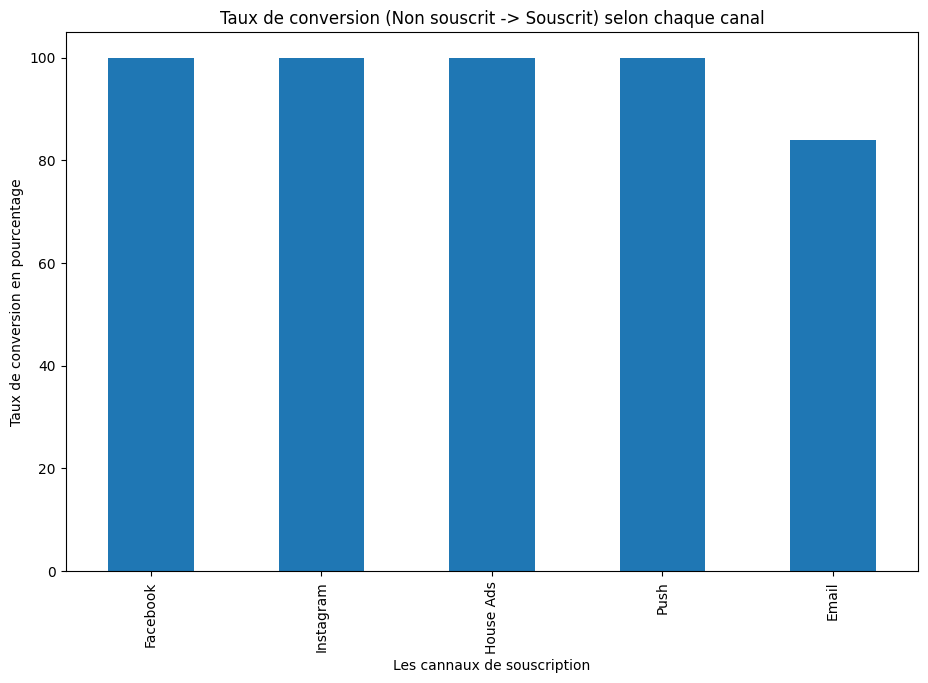

In [ ]:
#Taux de conversion en fonction du segment "Chaine de souscription"
plt.figure(figsize=(11,7))
taux_conv(marketing_df,["canal_d_abonnement"]).plot(kind="bar")
plt.title("Taux de conversion (Non souscrit -> Souscrit) selon chaque canal")
plt.xlabel("Les cannaux de souscription")
plt.ylabel("Taux de conversion en pourcentage")
plt.show()

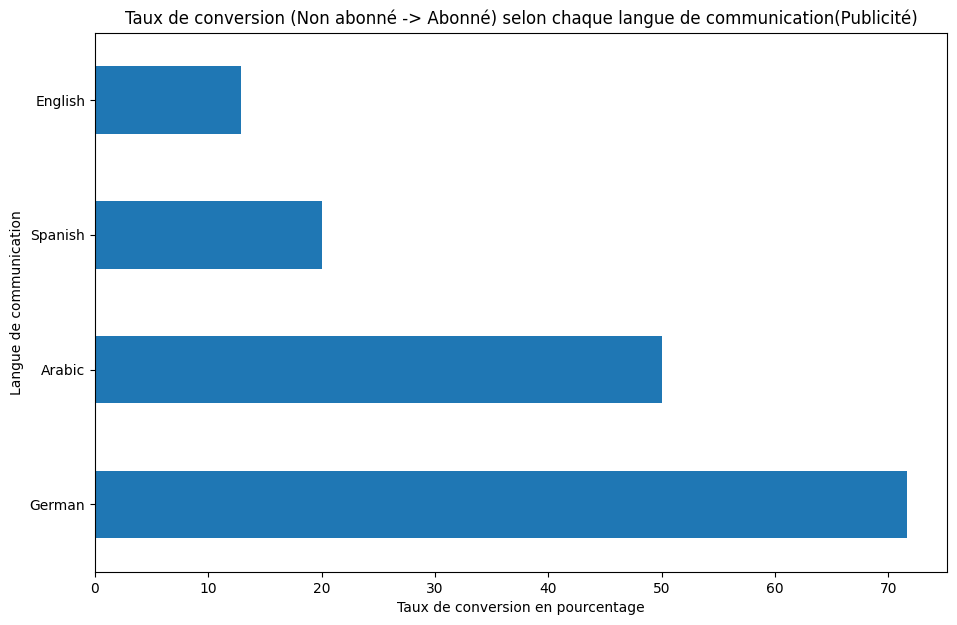

In [ ]:
#Taux de conversion en fonction du segment "Langue de communication"
plt.figure(figsize=(11,7))
taux_conv(marketing_df,["langue_de_publicite"]).plot(kind="barh")
plt.title("Taux de conversion (Non abonné -> Abonné) selon chaque langue de communication(Publicité)")
plt.xlabel("Taux de conversion en pourcentage")
plt.ylabel("Langue de communication")
plt.show()

Les campagnes marketing en Allemand semblent être plus efficaces que celles dans les autres
langues en termes de conversion des utilisateurs.

❖ TAUX DE CONVERSION JOURNALIER

In [ ]:
marketing_df.dtypes

,0
id_utilisateur,object
date_exposition_publicite,datetime64[ns]
canal_marketing,object
variante,object
converti,object
langue_de_publicite,object
langue_preferee,object
tranche_d_age,object
date_souscription,datetime64[ns]
date_desinscription,datetime64[ns]


In [ ]:
""" Pour ce faire nous allons le calculer avec la toute précédente fonction
qu'on avait définit mais cette fois ci selon le segment Jour de souscription """
taux_conversion_journalier = taux_conv(marketing_df,["date_exposition_publicite"]) #Le segment ici c'est la date (date_exposition_publicite)
taux_conversion_journalier


,id_utilisateur
date_exposition_publicite,
2018-01-16,25.515464
2018-01-17,21.951220
2018-01-07,14.181818
2018-01-05,12.539185
2018-01-25,12.500000
2018-01-09,12.500000
2018-01-22,12.359551
2018-01-23,12.209302
2018-01-10,11.869436


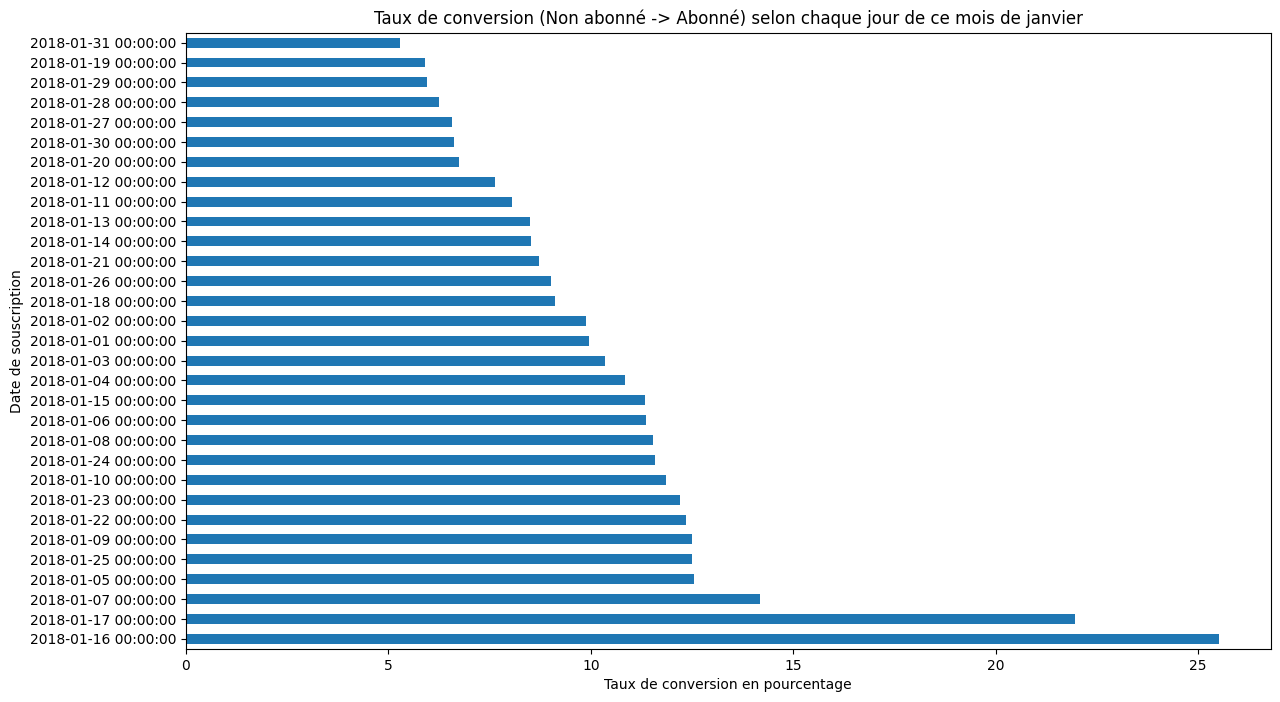

In [ ]:
#Taux de conversion en fonction du segment "date de souscription"
plt.figure(figsize=(14,8))
taux_conversion_journalier.plot(kind="barh")
plt.title("Taux de conversion (Non abonné -> Abonné) selon chaque jour de ce mois de janvier")
plt.xlabel("Taux de conversion en pourcentage")
plt.ylabel("Date de souscription")
plt.show()

Jusqu'à présent, nous avons calculé des taux de rétention et de reconversion en fonction d'une
seule variable. Mainenant dans ce qui suit on va essayer de voir plus loin qu'une seule variable

❖ TAUX DE CONVERSION JOURNALIER PAR GROUPE D'AGES

In [ ]:
taux_conv_journalier_par_groupes_dages = taux_conv(marketing_df, ["date_exposition_publicite","tranche_d_age"])
taux_conv_journalier_par_groupes_dages


date_exposition_publicite  tranche_d_age
2018-01-16                 24-30 years      40.845070
                           19-24 years      37.142857
                           0-18 years       33.846154
2018-01-17                 19-24 years      31.578947
2018-01-25                 19-24 years      30.555556
                                              ...    
2018-01-28                 55+ years         0.000000
2018-01-29                 30-36 years       0.000000
                           36-45 years       0.000000
                           55+ years         0.000000
2018-01-31                 30-36 years       0.000000
Name: id_utilisateur, Length: 217, dtype: float64

In [ ]:
taux_conv_journalier_par_groupes_dages = pd.DataFrame(taux_conv_journalier_par_groupes_dages.unstack(level=1))
# level = 1 car c'est la variable age_group (position 1) qu'on veut désemballer
# l'indexation dans python débute par 0
taux_conv_journalier_par_groupes_dages.head()

tranche_d_age,0-18 years,19-24 years,24-30 years,30-36 years,36-45 years,45-55 years,55+ years
date_exposition_publicite,,,,,,,
2018-01-01,15.517241,19.672131,10.526316,4.081633,4.255319,2.222222,8.695652
2018-01-02,18.032787,16.438356,11.475410,4.000000,4.347826,4.347826,2.439024
2018-01-03,10.204082,20.895522,15.094340,4.255319,6.000000,4.761905,4.347826
2018-01-04,11.764706,20.000000,18.367347,4.545455,4.347826,6.122449,7.317073
2018-01-05,14.285714,25.000000,13.636364,9.090909,6.818182,4.651163,8.888889


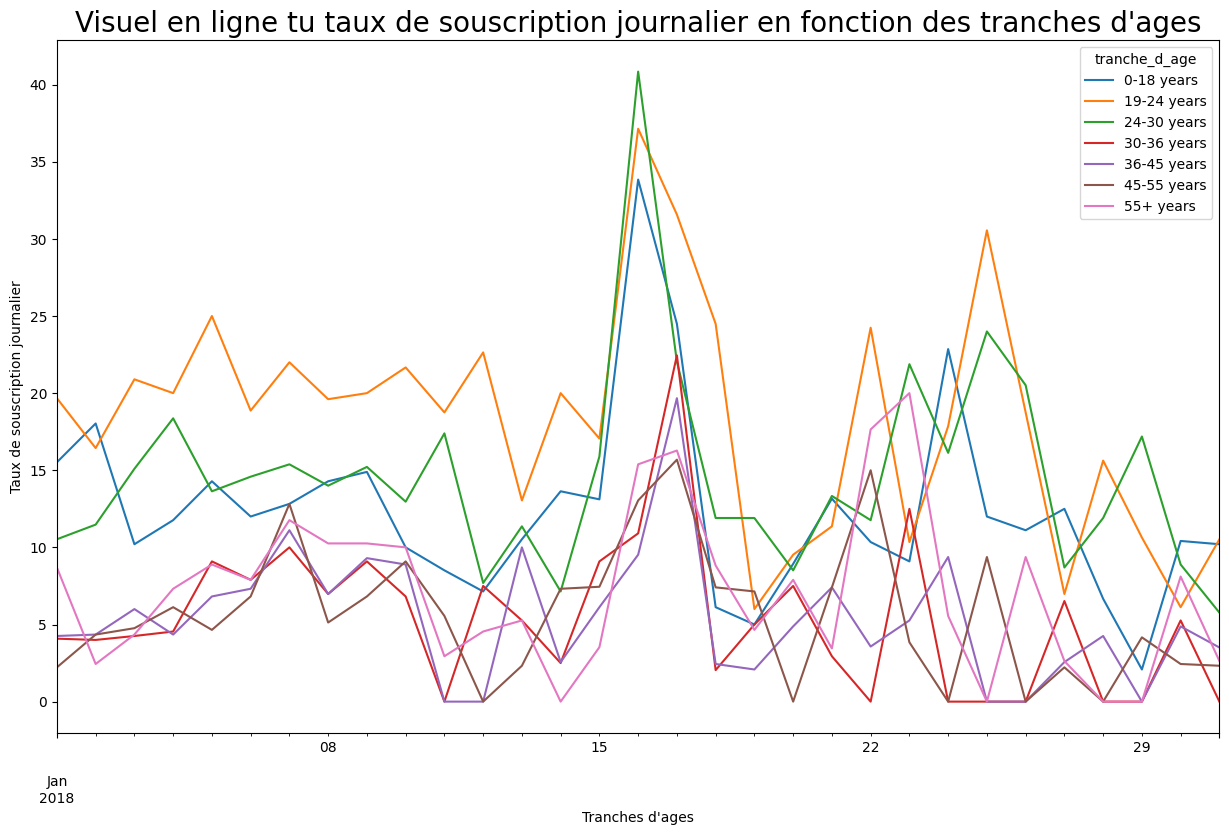

In [ ]:
""" Effectuons un visualisation en ligne de la distribution de cette DataFrame en lignes """
taux_conv_journalier_par_groupes_dages.plot(kind="line", figsize=(15, 9))
plt.title("Visuel en ligne tu taux de souscription journalier en fonction des tranches d'ages",size = 16, fontsize = 20)
plt.xlabel("Tranches d'ages")
plt.ylabel("Taux de souscription journalier")
plt.show()


❖ TAUX DE CONVERSION JOURNALIER PAR CANAL MARKETING

In [ ]:
taux_conv_journalier_par_canal = taux_conv(marketing_df, ["date_exposition_publicite","canal_marketing"])
taux_conv_journalier_par_canal

,,id_utilisateur
date_exposition_publicite,canal_marketing,
2018-01-01,Email,100.000000
2018-01-02,Email,100.000000
2018-01-05,Email,100.000000
2018-01-25,Email,100.000000
2018-01-23,Email,100.000000
...,...,...
2018-01-10,Push,2.857143
2018-01-05,Push,2.777778
2018-01-12,House Ads,2.721088


In [ ]:
taux_conv_journalier_par_canal = pd.DataFrame(taux_conv_journalier_par_canal.unstack(level = 1))#Conversion de l'ancienne structure de données en DataFrame
taux_conv_journalier_par_canal

canal_marketing,Email,Facebook,House Ads,Instagram,Push
date_exposition_publicite,,,,,
2018-01-01,100.000000,11.764706,8.465608,10.666667,8.333333
2018-01-02,100.000000,9.836066,7.798165,12.903226,5.555556
2018-01-03,0.000000,8.064516,8.854167,17.187500,8.333333
2018-01-04,50.000000,13.846154,8.982036,12.698413,5.882353
2018-01-05,100.000000,11.290323,12.658228,15.942029,2.777778
2018-01-06,60.000000,11.111111,11.184211,9.523810,6.896552
2018-01-07,100.000000,9.615385,14.503817,17.543860,8.823529
2018-01-08,100.000000,13.636364,10.389610,12.500000,6.451613
2018-01-09,50.000000,12.068966,12.738854,15.254237,5.405405


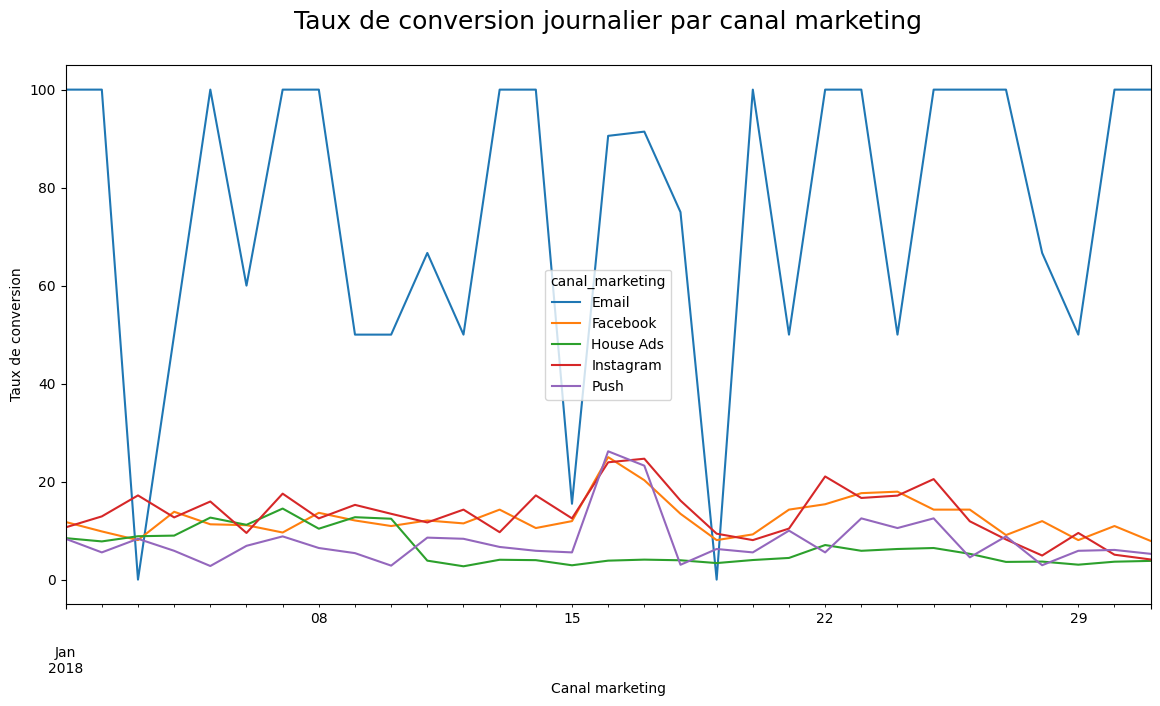

In [ ]:
# Visualisation des résultats
taux_conv_journalier_par_canal.plot(kind='line', figsize = (14, 7))
plt.title("Taux de conversion journalier par canal marketing\n", size = 20, fontsize=18)
plt.ylabel('Taux de conversion')
plt.xlabel("Canal marketing")
plt.show()

❖ TAUX DE CONVERSION PAR JOUR DE SEMAINE ET PAR CANAL
MARKETING

Les utilisateurs sont -ils plus susceptibles de convertir le week-end par rapport aux autres jours
de la semaine ?

In [ ]:
#Renomons l'ancienne colonne jour_de_semaine
marketing_df = marketing_df.rename(columns={"jour_de_semaine":"jour_d_abonnement"})

In [ ]:
#Jour de la semaine ou l'annonce a été diffusé
marketing_df["jour_de_diffusion"] = marketing_df["date_exposition_publicite"].dt.dayofweek
# Taux de conversion par jour de la semaine (de diffusion) et par canal marketing
taux_conv_par_jour_de_diffusion_et_canal = taux_conv(marketing_df,["jour_de_diffusion","canal_marketing"])
taux_conv_par_jour_de_diffusion_et_canal = pd.DataFrame(taux_conv_par_jour_de_diffusion_et_canal.unstack(level=1))
taux_conv_par_jour_de_diffusion_et_canal



canal_marketing,Email,Facebook,House Ads,Instagram,Push
jour_de_diffusion,,,,,
0.0,16.262136,11.960133,6.265985,12.251656,6.451613
1.0,90.625000,14.788732,7.031250,15.194346,11.585366
2.0,83.720930,12.703583,7.526882,15.015974,10.588235
3.0,72.727273,13.333333,5.903399,14.349776,6.779661
4.0,66.666667,11.013216,6.227758,12.987013,5.555556
5.0,81.818182,10.937500,5.756579,8.870968,6.976744
6.0,75.000000,11.607143,6.521739,12.719298,6.557377


<Figure size 1200x700 with 0 Axes>

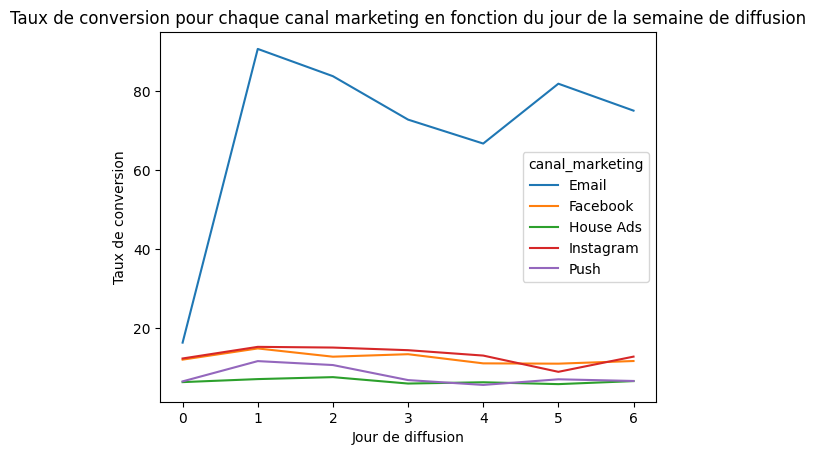

In [ ]:
#Effectuons un visuel sur cette mesure calculée
plt.figure(figsize=(12,7))
taux_conv_par_jour_de_diffusion_et_canal.plot(kind="line")
plt.title("Taux de conversion pour chaque canal marketing en fonction du jour de la semaine de diffusion")
plt.xlabel("Jour de diffusion")
plt.ylabel("Taux de conversion")
plt.show()

Nous avons calculé les taux de conversion et de rétention pour divers segments ou combinaison
de segments mais il y a d’autres types d’analyses que nous pouvons encore effectuer.

❖ PREFERENCES JOURNALIERES LINGUISTIQUES DES UTILISATEURS

In [ ]:
#Dans un premier temps déterminons pour chaque langue préférée et à chaque date
n_utilisateurs_uniques_par_langue_favoris_a_chaque_date = marketing_df.groupby(["langue_preferee","date_exposition_publicite"])["id_utilisateur"].nunique()
n_utilisateurs_uniques_par_langue_favoris_a_chaque_date

langue_preferee  date_exposition_publicite
Arabic           2018-01-01                    4
                 2018-01-02                    4
                 2018-01-03                    3
                 2018-01-04                    2
                 2018-01-05                    1
                                              ..
Spanish          2018-01-27                   13
                 2018-01-28                   22
                 2018-01-29                   18
                 2018-01-30                   19
                 2018-01-31                   17
Name: id_utilisateur, Length: 121, dtype: int64

In [ ]:
n_utilisateurs_uniques_par_langue_favoris_a_chaque_date = pd.DataFrame(n_utilisateurs_uniques_par_langue_favoris_a_chaque_date.unstack(level=0))
#Level 0 car c'est la première colonne que je veux desempiler cette fois ci
n_utilisateurs_uniques_par_langue_favoris_a_chaque_date

langue_preferee,Arabic,English,German,Spanish
date_exposition_publicite,,,,
2018-01-01,4.0,342.0,5.0,11.0
2018-01-02,4.0,355.0,5.0,10.0
2018-01-03,3.0,334.0,3.0,8.0
2018-01-04,2.0,305.0,2.0,14.0
2018-01-05,1.0,303.0,2.0,14.0
2018-01-06,3.0,291.0,3.0,11.0
2018-01-07,2.0,261.0,2.0,10.0
2018-01-08,NaN,296.0,6.0,10.0
2018-01-09,NaN,302.0,NaN,10.0


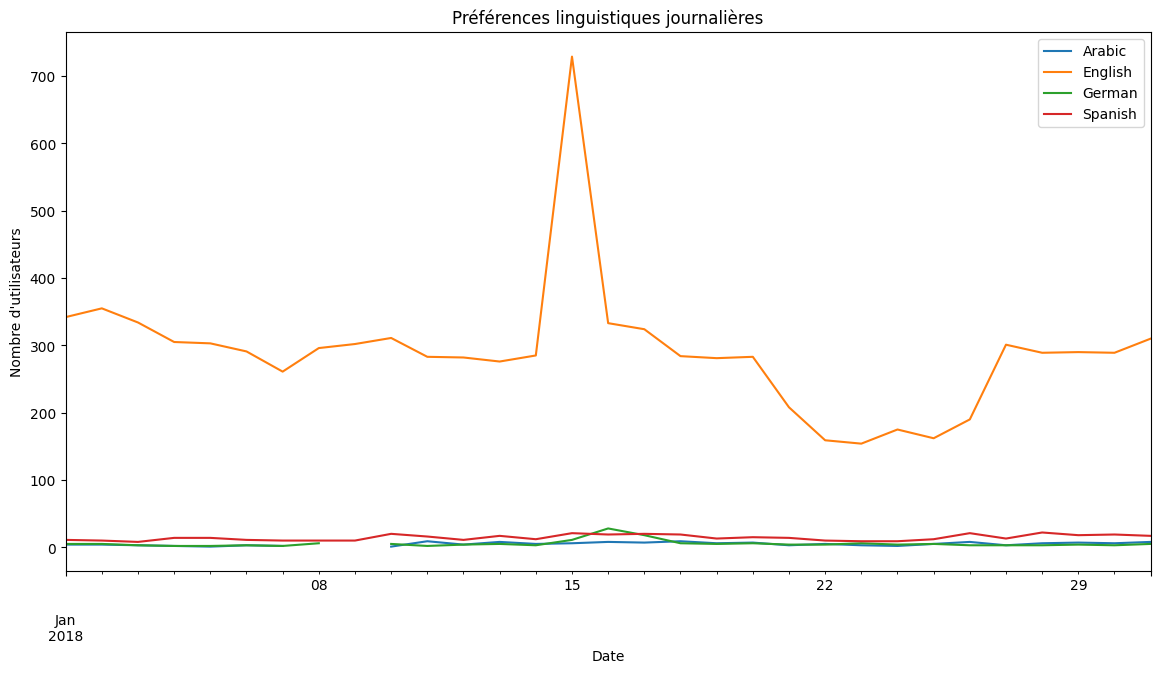

In [ ]:
#Petite Apercu graphique sur les résultats
n_utilisateurs_uniques_par_langue_favoris_a_chaque_date.plot(figsize=(14, 7))
plt.title('Préférences linguistiques journalières')
plt.xlabel('Date')
plt.ylabel("Nombre d'utilisateurs")
plt.legend(loc = 'upper right', labels = n_utilisateurs_uniques_par_langue_favoris_a_chaque_date.columns.values)
plt.show()

On peut clairement apercevoir que l'anglais est la langue préféré sur la durée

PREFERENCES LINGUISTIQUES PAR GROUPE D'AGE

In [ ]:
# Nombre d'utilisateurs par groupe d'âges et langues préférées
n_utilisateurs_par_groupe_d_age_et_langue_favori = marketing_df.groupby(["langue_preferee","tranche_d_age"])["id_utilisateur"].nunique()
n_utilisateurs_par_groupe_d_age_et_langue_favori = pd.DataFrame(n_utilisateurs_par_groupe_d_age_et_langue_favori.unstack(0))
n_utilisateurs_par_groupe_d_age_et_langue_favori

langue_preferee,Arabic,English,German,Spanish
tranche_d_age,,,,
0-18 years,16,1126,24,43
19-24 years,18,1218,23,51
24-30 years,16,1121,29,54
30-36 years,12,978,12,57
36-45 years,13,993,14,39
45-55 years,14,978,20,47
55+ years,17,922,9,34


<Figure size 1200x800 with 0 Axes>

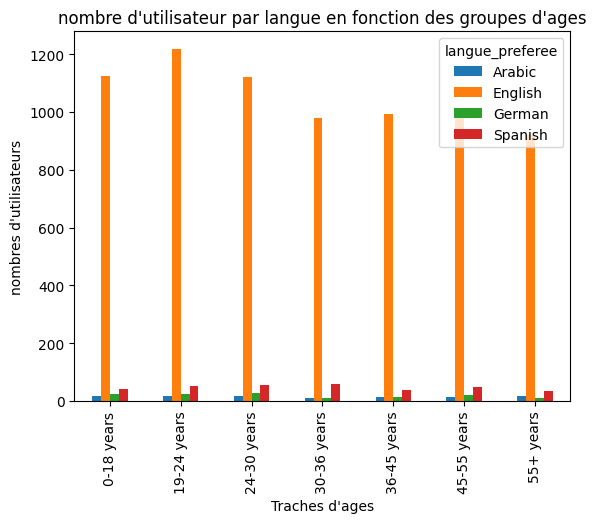

In [ ]:
#Data viz
plt.figure(figsize = (12,8))
n_utilisateurs_par_groupe_d_age_et_langue_favori.plot(kind="bar")
plt.title("nombre d'utilisateur par langue en fonction des groupes d'ages")
plt.xlabel("Traches d'ages")
plt.ylabel("nombres d'utilisateurs")
plt.show()

L’Anglais demeure la langue préférée quel que soit le groupe d'âges.

CANAUX MARKETING SELON LES GROUPES D'AGES   
Supposons que les décideurs de l'entreprise veulent savoir si les canaux marketing atteignent
tous les utilisateurs de manière égale ou s'il y a une différence. Nous allons donc créer un
graphique indiquant le nombre de personnes atteintes par chaque canal marketing par âge.

In [ ]:
# Nombre d'utilisateurs par groupe d'âges et canal d'acquisition
canal_age = marketing_df.groupby(['tranche_d_age', 'canal_marketing'])['id_utilisateur'].nunique()
canal_age = pd.DataFrame(canal_age.unstack(level=1))
canal_age

canal_marketing,Email,Facebook,House Ads,Instagram,Push
tranche_d_age,,,,,
0-18 years,91,256,585,292,184
19-24 years,107,331,643,301,144
24-30 years,116,289,587,268,180
30-36 years,60,238,600,252,83
36-45 years,63,217,505,268,192
45-55 years,64,289,567,218,82
55+ years,53,175,538,199,117


<Figure size 2000x1200 with 0 Axes>

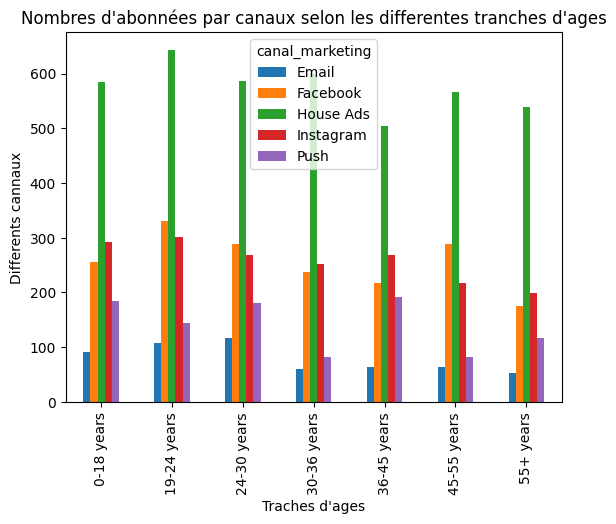

In [ ]:
#Data viz
plt.figure(figsize = (20,12))
canal_age.plot(kind="bar")
plt.title("Nombres d'abonnées par canaux selon les differentes tranches d'ages")
plt.xlabel("Traches d'ages")
plt.ylabel("Differents cannaux")
plt.show()

**CONCLUSION:**   
Le Marketing est l'un des départements stratégiques les plus importants pour une entreprise.
Pouvoir analyser les données clients afin d'en tirer des insights utiles est une compétence
hautement importante. Pandas est une librairie très puissante pour faire l'analyse des données
avec Python.
A travers ce projet, nous avons utilisé quelques fonctionnalités de Pandas afin d'effectuer une
analyse descriptive de la campagne marketing d'une entreprise de services en ligne.